# Sentiment Analysis of Product Reviews
**Dataset:** UCI Sentiment Labelled Sentences  
**Sources:** Amazon, IMDb, Yelp  
**Models:** Logistic Regression · Multinomial Naive Bayes · Random Forest

## 0. Install Dependencies

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn nltk wordcloud requests

## 1. Imports & Dataset Loading

In [2]:
import os
import re
import string
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

All imports successful.


In [3]:
# Download UCI dataset automatically
DATA_URL = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
ZIP_PATH = 'sentiment_labelled_sentences.zip'
DATA_DIR = 'sentiment labelled sentences'

if not os.path.isdir(DATA_DIR):
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    print('Done.')
else:
    print('Dataset already present.')

# Load the three source files
files = {
    'Amazon': os.path.join(DATA_DIR, 'amazon_cells_labelled.txt'),
    'IMDb':   os.path.join(DATA_DIR, 'imdb_labelled.txt'),
    'Yelp':   os.path.join(DATA_DIR, 'yelp_labelled.txt'),
}

frames = []
for source, path in files.items():
    df_src = pd.read_csv(path, sep='\t', header=None, names=['review', 'sentiment'])
    df_src['source'] = source
    frames.append(df_src)

df = pd.concat(frames, ignore_index=True)
df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 1: 'Positive'})

print(f'Total samples : {len(df):,}')
print(f'Columns       : {list(df.columns)}')
df.head(10)

Done.
Total samples : 2,748
Columns       : ['review', 'sentiment', 'source', 'sentiment_label']


,review,sentiment,source,sentiment_label
0,So there is no way for me to plug it in here i...,0,Amazon,Negative
1,"Good case, Excellent value.",1,Amazon,Positive
2,Great for the jawbone.,1,Amazon,Positive
3,Tied to charger for conversations lasting more...,0,Amazon,Negative
4,The mic is great.,1,Amazon,Positive
5,I have to jiggle the plug to get it to line up...,0,Amazon,Negative
6,If you have several dozen or several hundred c...,0,Amazon,Negative
7,If you are Razr owner...you must have this!,1,Amazon,Positive
8,"Needless to say, I wasted my money.",0,Amazon,Negative
9,What a waste of money and time!.,0,Amazon,Negative


## 2. Exploratory Data Analysis (EDA)

### 2.1 Class Distribution

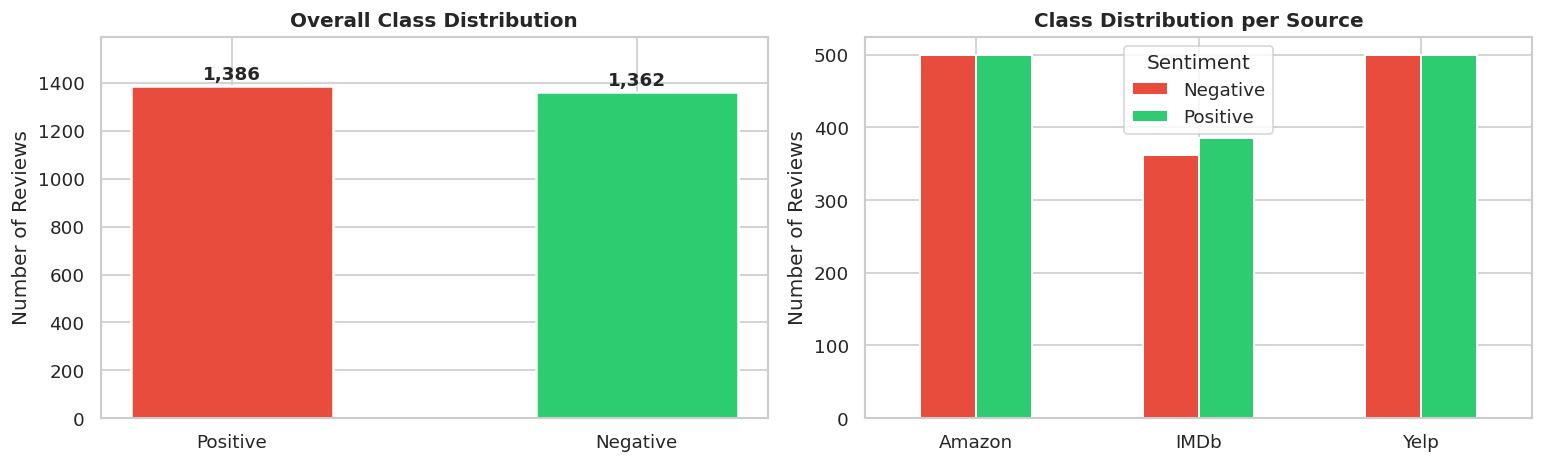


Class balance:
                 count   pct
sentiment_label             
Positive          1386  50.4
Negative          1362  49.6


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall class balance
counts = df['sentiment_label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Overall Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, counts.max() * 1.15)

# Per-source breakdown
src_counts = df.groupby(['source', 'sentiment_label']).size().unstack()
src_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                edgecolor='white', linewidth=1.2, rot=0)
axes[1].set_title('Class Distribution per Source', fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_xlabel('')
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

print('\nClass balance:')
print(counts.to_frame('count').assign(pct=lambda x: (x['count'] / len(df) * 100).round(1)))

### 2.2 Word Clouds - Positive vs Negative Reviews

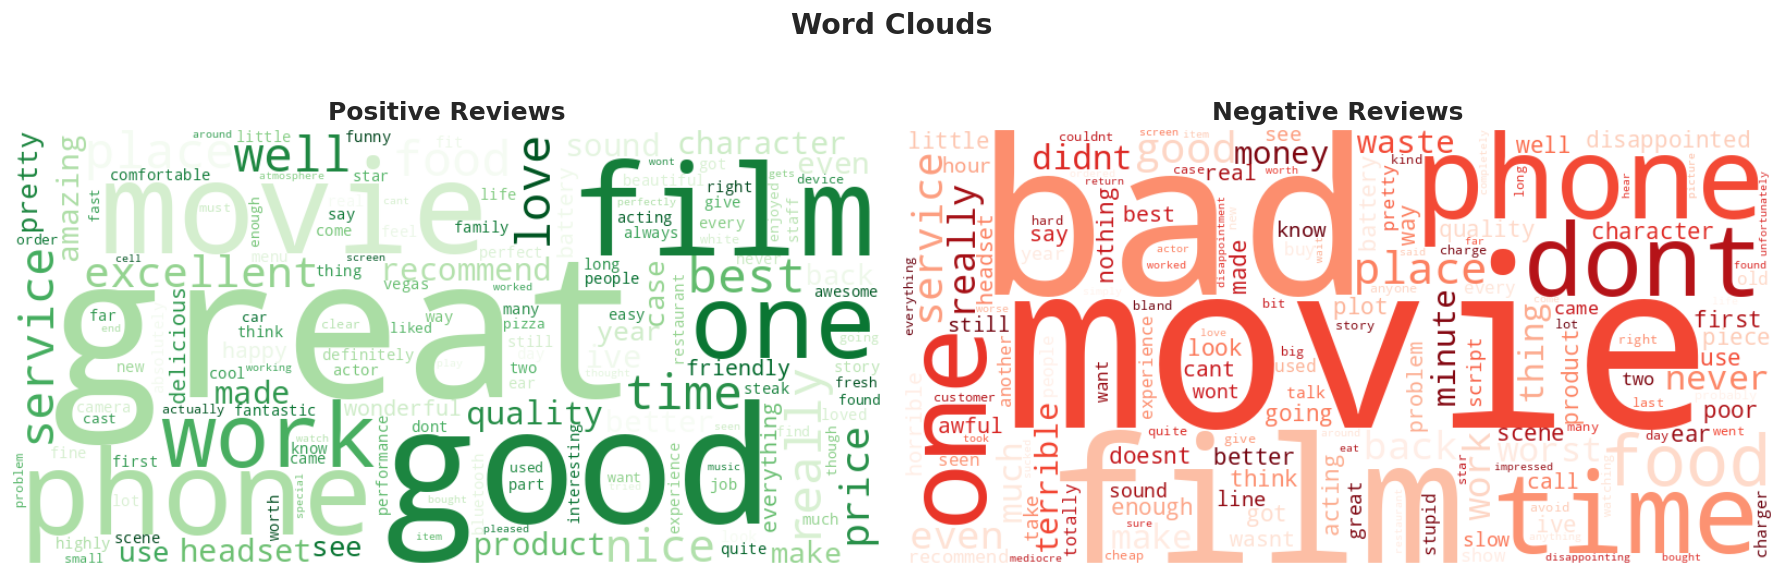

In [5]:
stop_words = set(stopwords.words('english'))

def make_corpus(series):
    """Join reviews, strip punctuation, remove stopwords."""
    text = ' '.join(series.str.lower())
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

pos_corpus = make_corpus(df.loc[df['sentiment'] == 1, 'review'])
neg_corpus = make_corpus(df.loc[df['sentiment'] == 0, 'review'])

wc_kwargs = dict(width=800, height=400, background_color='white',
                 max_words=150, collocations=False)

wc_pos = WordCloud(colormap='Greens', **wc_kwargs).generate(pos_corpus)
wc_neg = WordCloud(colormap='Reds',   **wc_kwargs).generate(neg_corpus)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, wc, title in zip(axes, [wc_pos, wc_neg],
                          ['Positive Reviews', 'Negative Reviews']):
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold')

plt.suptitle('Word Clouds', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Top-20 Most Frequent Words (by Sentiment)

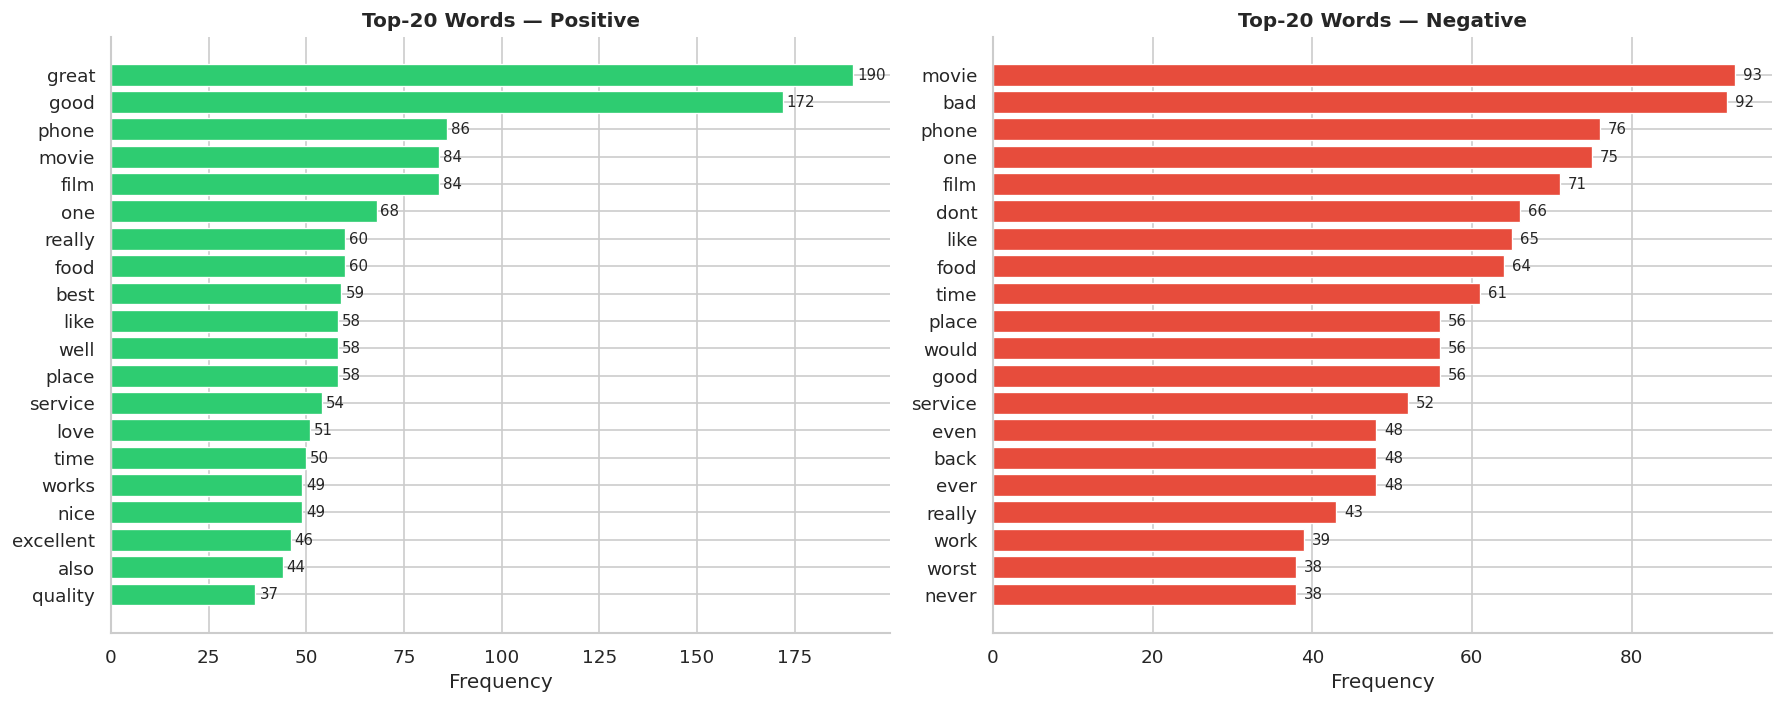

In [6]:
from collections import Counter

def top_words(corpus, n=20):
    return pd.DataFrame(Counter(corpus.split()).most_common(n),
                        columns=['word', 'count'])

top_pos = top_words(pos_corpus)
top_neg = top_words(neg_corpus)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, data, color, title in zip(
        axes, [top_pos, top_neg], ['#2ecc71', '#e74c3c'],
        ['Top-20 Words — Positive', 'Top-20 Words — Negative']):
    bars = ax.barh(data['word'][::-1], data['count'][::-1],
                   color=color, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, data['count'][::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Review Length Distribution

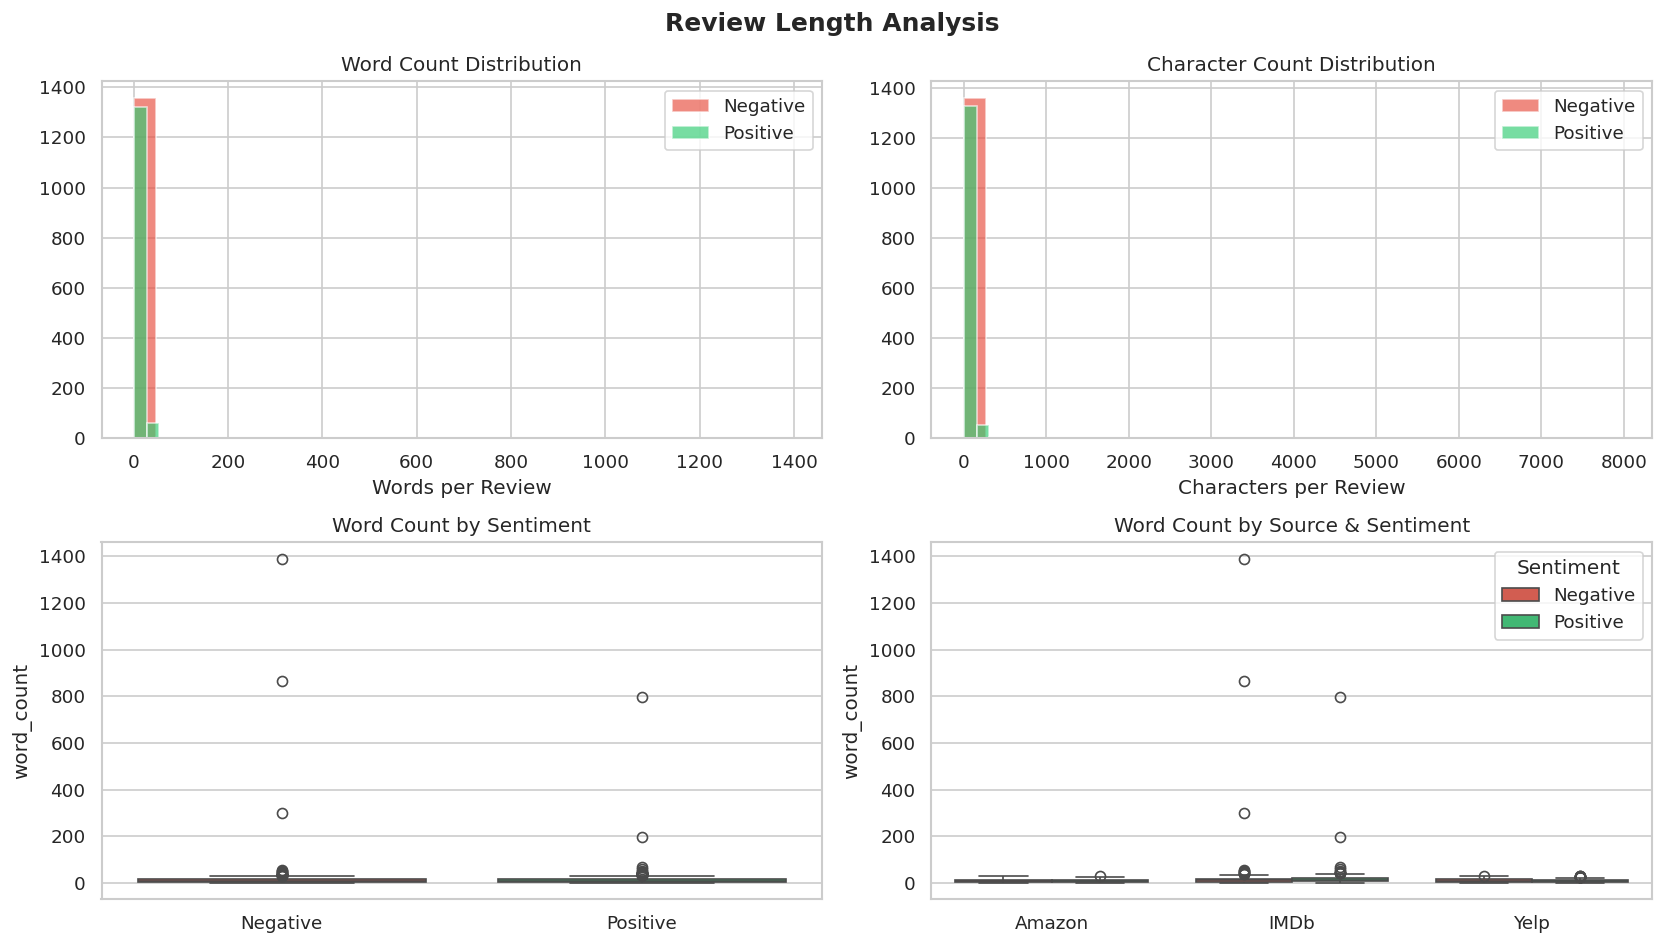

                word_count                                            \
                     count  mean   std  min  25%   50%   75%     max   
sentiment_label                                                        
Negative            1362.0  13.6  45.2  1.0  6.0  10.5  16.0  1390.0   
Positive            1386.0  12.4  23.1  1.0  5.0  10.0  16.0   797.0   

                char_count                                              
                     count  mean    std  min   25%   50%   75%     max  
sentiment_label                                                         
Negative            1362.0  74.3  255.1  8.0  33.0  57.0  88.0  7944.0  
Positive            1386.0  68.8  130.1  7.0  32.0  54.0  87.0  4487.0  


In [7]:
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
df['char_count'] = df['review'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

palette = {'Positive': '#2ecc71', 'Negative': '#e74c3c'}

# Word count histogram
for label, grp in df.groupby('sentiment_label'):
    axes[0, 0].hist(grp['word_count'], bins=30, alpha=0.65,
                    label=label, color=palette[label], edgecolor='white')
axes[0, 0].set_title('Word Count Distribution')
axes[0, 0].set_xlabel('Words per Review')
axes[0, 0].legend()

# Char count histogram
for label, grp in df.groupby('sentiment_label'):
    axes[0, 1].hist(grp['char_count'], bins=30, alpha=0.65,
                    label=label, color=palette[label], edgecolor='white')
axes[0, 1].set_title('Character Count Distribution')
axes[0, 1].set_xlabel('Characters per Review')
axes[0, 1].legend()

# Box plots
sns.boxplot(data=df, x='sentiment_label', y='word_count',
            palette=palette, ax=axes[1, 0], order=['Negative', 'Positive'])
axes[1, 0].set_title('Word Count by Sentiment')
axes[1, 0].set_xlabel('')

sns.boxplot(data=df, x='source', y='word_count', hue='sentiment_label',
            palette=palette, ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Source & Sentiment')
axes[1, 1].set_xlabel('')
axes[1, 1].legend(title='Sentiment')

plt.suptitle('Review Length Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(df.groupby('sentiment_label')[['word_count', 'char_count']].describe().round(1))

## 3. Preprocessing

### 3.1 Text Cleaning

In [8]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Lowercase → remove punctuation → remove stopwords."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)

# Sanity check
sample = df[['review', 'clean_review', 'sentiment_label']].sample(3, random_state=SEED)
pd.set_option('display.max_colwidth', 100)
sample

,review,clean_review,sentiment_label
2516,"It's close to my house, it's low-key, non-fancy, affordable prices, good food.",close house lowkey nonfancy affordable prices good food,Positive
2642,If you stay in Vegas you must get breakfast here at least once.,stay vegas must get breakfast least,Positive
1359,"Let's start with all the problemsthe acting, especially from the lead professor, was very, very...",lets start acting especially lead professor bad,Negative


### Why TF-IDF?

We use **TF-IDF (Term Frequency–Inverse Document Frequency)** instead of simple CountVectorizer for two reasons:
- **Down-weights common words** that appear frequently across all reviews (e.g. *'product'*, *'item'*) but carry little discriminative signal.
- **Up-weights rare but informative words** (e.g. *'broken'*, *'fantastic'*) that are strong indicators of sentiment.

 We also include **bigrams** (`ngram_range=(1,2)`) to capture phrases like *'not good'* or *'very bad'* that would be lost with unigrams alone.

### 3.2 TF-IDF Vectorization & Train/Test Split

In [9]:
X_raw = df['clean_review'].values
y     = df['sentiment'].values

# 80 / 20 stratified split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)

# TF-IDF (unigrams + bigrams, max 10 000 features)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10_000,
                         min_df=2, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f'Train samples : {X_train.shape[0]:,}  |  features : {X_train.shape[1]:,}')
print(f'Test  samples : {X_test.shape[0]:,}  |  features : {X_test.shape[1]:,}')
print(f'\nClass balance — train: {y_train.mean():.2%} positive')
print(f'Class balance — test : {y_test.mean():.2%} positive')

Train samples : 2,198  |  features : 2,264
Test  samples : 550  |  features : 2,264

Class balance — train: 50.45% positive
Class balance — test : 50.36% positive


## 4. Model Training

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=SEED, solver='lbfgs'
    ),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED
    ),
}

trained = {}
for name, clf in models.items():
    clf.fit(X_train, y_train)
    trained[name] = clf
    print(f'[OK] {name} trained.')

[OK] Logistic Regression trained.
[OK] Multinomial Naive Bayes trained.
[OK] Random Forest trained.


## 5. Evaluation

### 5.1 Per-Model Metrics & Confusion Matrices

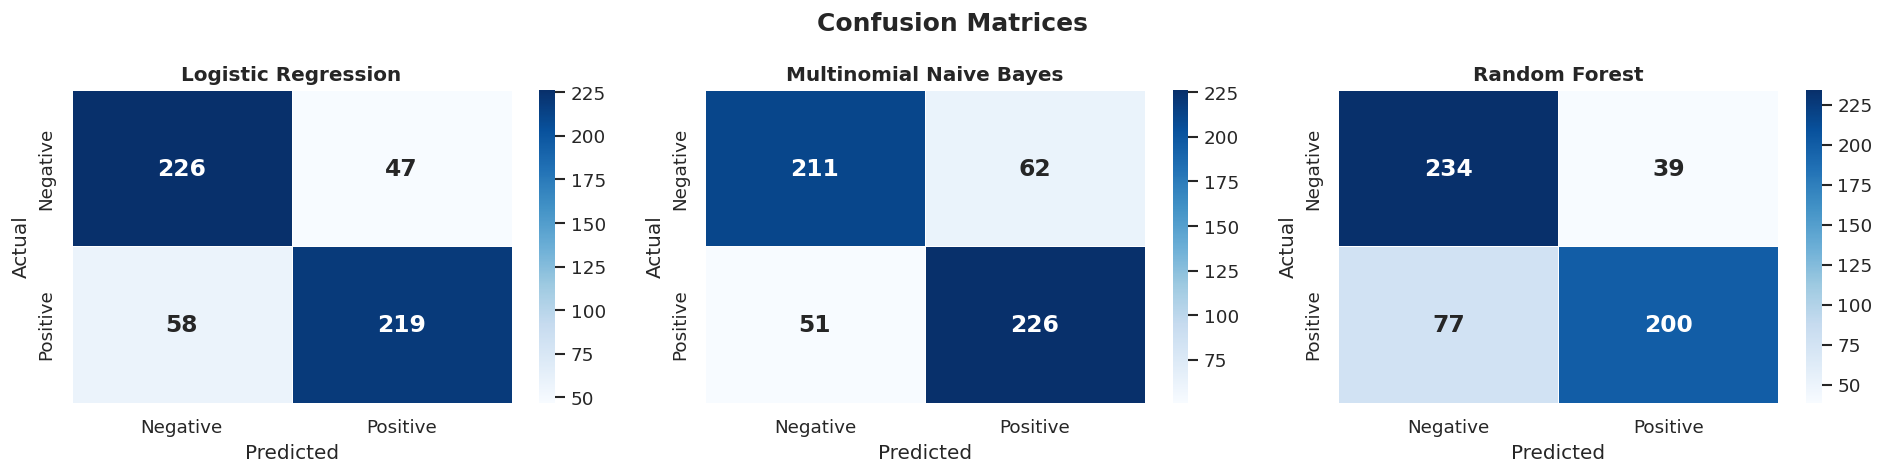

In [11]:
results = []

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, clf) in zip(axes, trained.items()):
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'F1': f1, 'ROC-AUC': auc})

    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 ROC-AUC Curves

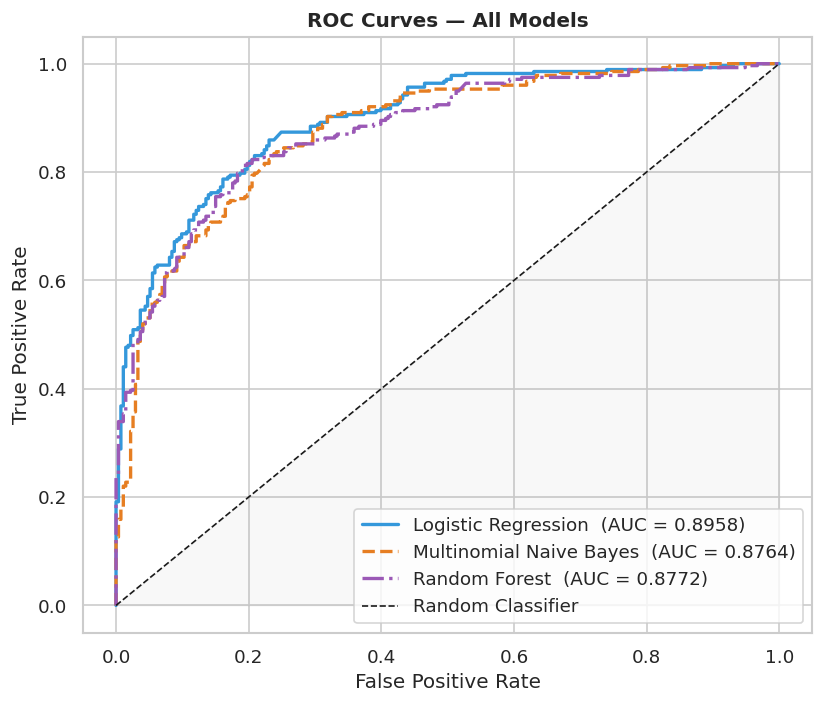

In [12]:
line_styles = ['-', '--', '-.']
colors_roc  = ['#3498db', '#e67e22', '#9b59b6']

plt.figure(figsize=(7, 6))

for (name, clf), ls, color in zip(trained.items(), line_styles, colors_roc):
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2,
             label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 Comparative Metrics Table

In [13]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)

# Highlight best value per column
styled = results_df.style.highlight_max(
    axis=0, color='#d5f5e3', props='font-weight: bold'
).format('{:.4f}')

print('=== Model Comparison ===')
display(styled)

best_model_name = results_df['F1'].idxmax()
print(f'\nBest model by F1-score: {best_model_name}  '
      f'(F1 = {results_df.loc[best_model_name, "F1"]:.4f})')

=== Model Comparison ===


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8091,0.8233,0.7906,0.8066,0.8958
Multinomial Naive Bayes,0.7945,0.7847,0.8159,0.8000,0.8764
Random Forest,0.7891,0.8368,0.7220,0.7752,0.8772



Best model by F1-score: Logistic Regression  (F1 = 0.8066)


### 5.4 Visual Metric Comparison

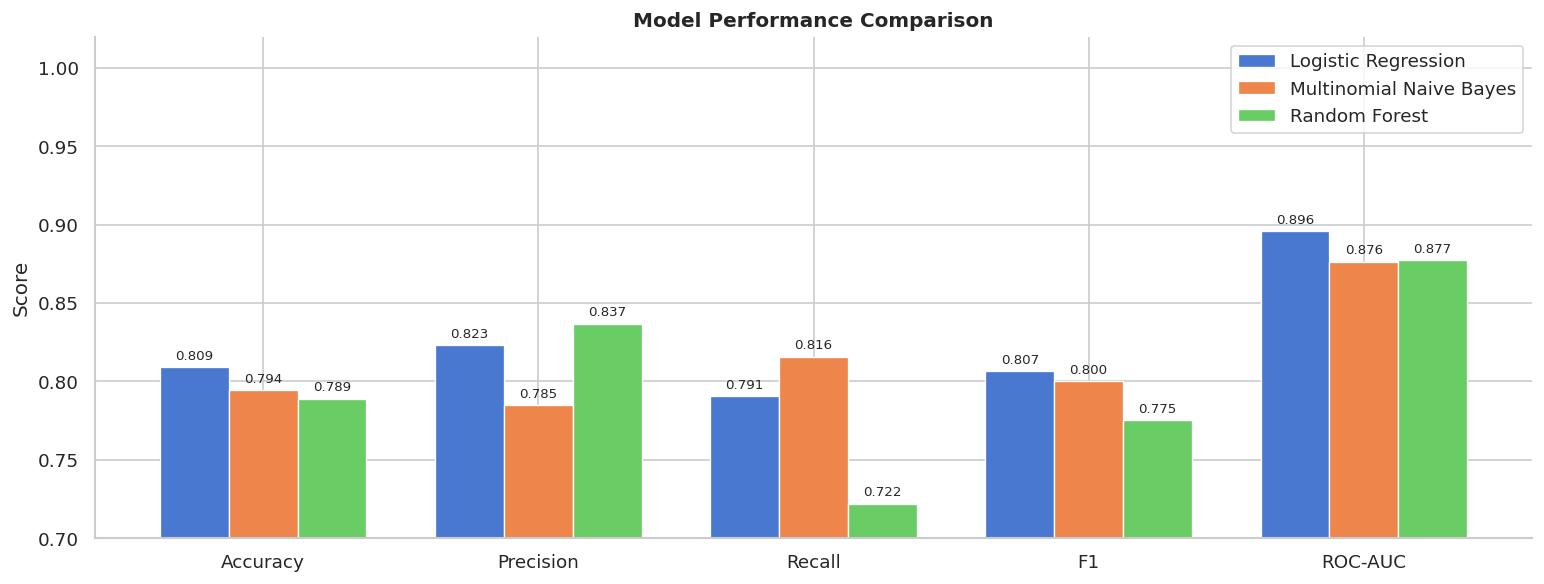

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, row[metrics], width,
                  label=model_name, edgecolor='white', linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0.7, 1.02)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 5.5 Feature Importance (Top Predictive Words)

Using Logistic Regression coefficients to identify which words most strongly push the model toward **Positive** or **Negative** predictions.

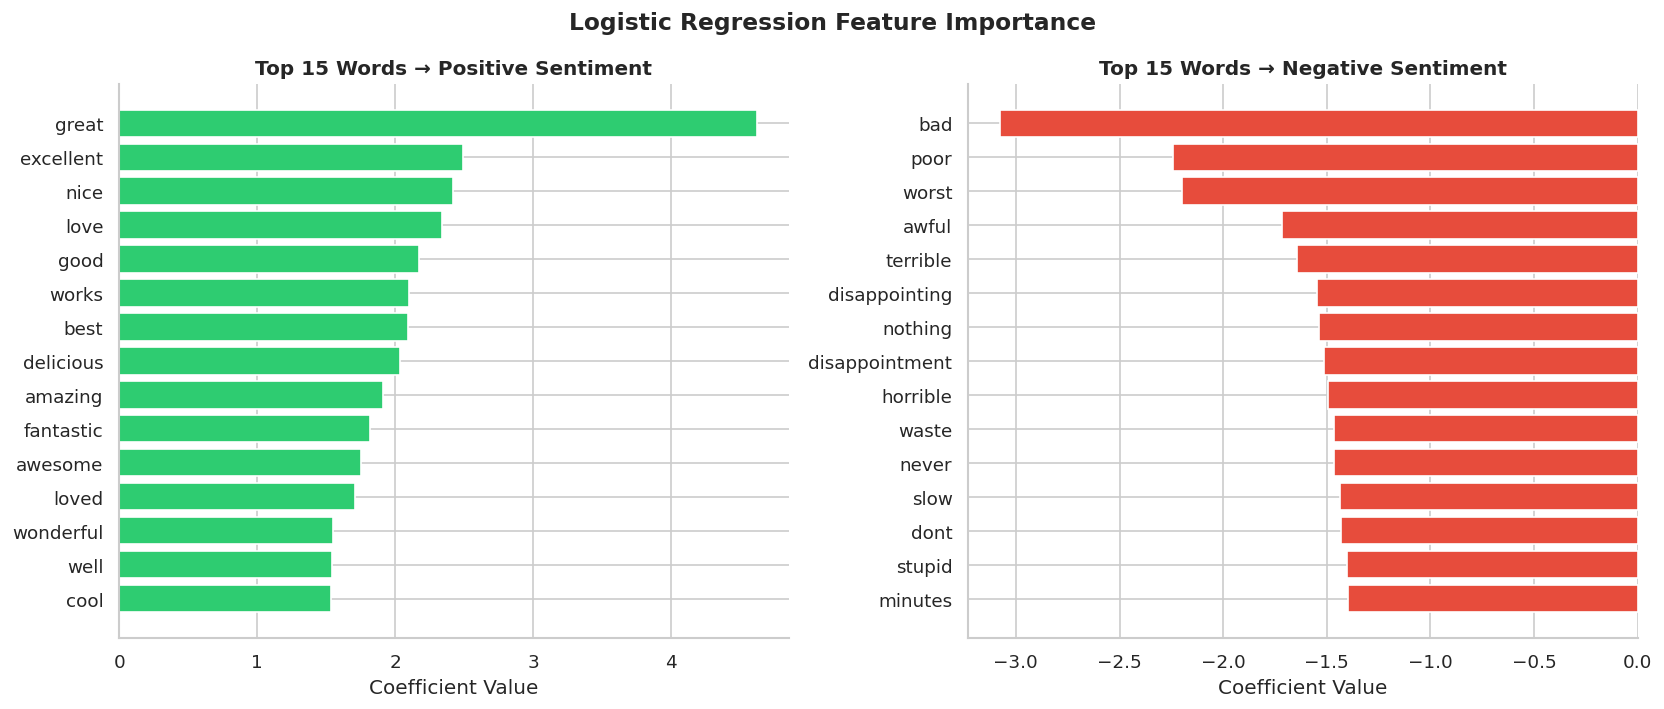

Most positive words: great, excellent, nice, love, good, works, best, delicious
Most negative words: bad, poor, worst, awful, terrible, disappointing, nothing, disappointment


In [15]:
# Feature importance via Logistic Regression coefficients
lr_model = trained['Logistic Regression']
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_n = 15

# Top positive and negative words
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]

top_pos_words = feature_names[top_pos_idx]
top_pos_vals  = coefs[top_pos_idx]

top_neg_words = feature_names[top_neg_idx]
top_neg_vals  = coefs[top_neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
axes[0].barh(top_pos_words[::-1], top_pos_vals[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 15 Words → Positive Sentiment', fontweight='bold')
axes[0].set_xlabel('Coefficient Value')
axes[0].spines[['top', 'right']].set_visible(False)

# Negative words
axes[1].barh(top_neg_words[::-1], top_neg_vals[::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 15 Words → Negative Sentiment', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Logistic Regression Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Most positive words:', ', '.join(top_pos_words[:8]))
print('Most negative words:', ', '.join(top_neg_words[:8]))

## 6. Interactive Demo

Type any product review text and the best-performing model will classify it as **Positive** or **Negative** with a confidence score.

In [16]:
# Select the best model by F1-score
best_clf = trained[best_model_name]
print(f'Using: {best_model_name}')
print('-' * 45)

def predict_sentiment(text: str) -> dict:
    """Clean, vectorize, and classify a raw review string."""
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned])
    label   = best_clf.predict(vec)[0]
    proba   = best_clf.predict_proba(vec)[0]
    confidence = proba[label]
    return {
        'sentiment'  : 'Positive' if label == 1 else 'Negative',
        'confidence' : confidence,
        'label'      : label,
    }

# Quick smoke-test on five diverse examples
test_examples = [
    "This product is absolutely amazing, I love it so much!",
    "Terrible quality. Broke after one day. Total waste of money.",
    "Decent product for the price, nothing spectacular.",
    "Fast shipping and great packaging. Works exactly as described.",
    "I'm extremely disappointed. The customer service was unhelpful.",
]

print(f'{"Review":<55} {"Sentiment":<12} {"Confidence"}')
print('=' * 80)
for ex in test_examples:
    res = predict_sentiment(ex)
    short = ex[:52] + '...' if len(ex) > 55 else ex
    emoji = '✅' if res['label'] == 1 else '❌'
    print(f'{short:<55} {emoji} {res["sentiment"]:<10}  {res["confidence"]:.1%}')

Using: Logistic Regression
---------------------------------------------
Review                                                  Sentiment    Confidence
This product is absolutely amazing, I love it so much!  ✅ Positive    80.0%
Terrible quality. Broke after one day. Total waste o... ❌ Negative    83.8%
Decent product for the price, nothing spectacular.      ❌ Negative    50.5%
Fast shipping and great packaging. Works exactly as ... ✅ Positive    92.9%
I'm extremely disappointed. The customer service was... ❌ Negative    78.9%


In [17]:
# Live interactive prompt
print('Enter a product review (or "quit" to exit):\n')
while True:
    user_input = input('Review > ').strip()
    if user_input.lower() in ('quit', 'exit', 'q', ''):
        print('Exiting demo.')
        break
    res = predict_sentiment(user_input)
    emoji = '😊' if res['label'] == 1 else '😞'
    print(f'  → {emoji}  {res["sentiment"]}  (confidence: {res["confidence"]:.1%})\n')

Enter a product review (or "quit" to exit):

Review > "This product is absolutely amazing, I love it!"
  → 😊  Positive  (confidence: 86.5%)

Review > "Decent product for the price, nothing spectacular."
  → 😞  Negative  (confidence: 50.5%)

Review > "Terrible quality. Broke after one day. Total waste."
  → 😞  Negative  (confidence: 77.1%)

Review > "Fast shipping and great packaging. Works as described."
  → 😊  Positive  (confidence: 92.0%)

Review > "I'm extremely disappointed. The customer service was unhelpful."
  → 😞  Negative  (confidence: 78.9%)

Review > quit
Exiting demo.
